In [2]:
!pip install mpi4py


[notice] A new release of pip is available: 24.3.1 -> 25.1
[notice] To update, run: C:\Users\Rishi\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
%pip install mpi4py
import tensorflow as tf
from mpi4py import MPI

# Load the MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images to [0, 1] and reshape for Conv2D
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0
x_train = x_train[..., tf.newaxis]
x_test  = x_test[..., tf.newaxis]

# Initialize MPI
comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

# Define the CNN model
def create_model():
    model = tf.keras.models.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Training function
def train(model, x_train, y_train, rank, size):
    n = len(x_train)
    chunk_size = n // size
    start = rank * chunk_size
    end = (rank + 1) * chunk_size if rank != size - 1 else n

    x_train_chunk = x_train[start:end]
    y_train_chunk = y_train[start:end]

    # Compile the model
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model on its data chunk
    model.fit(x_train_chunk, y_train_chunk, epochs=1, batch_size=32, verbose=0)

    # Evaluate and get local accuracy
    train_loss, train_acc = model.evaluate(x_train_chunk, y_train_chunk, verbose=0)

    # Reduce (average) training accuracy across all nodes
    train_acc = comm.allreduce(train_acc, op=MPI.SUM)
    return train_acc / size

# Main training loop
epochs = 5
for epoch in range(epochs):
    model = create_model()  # Each process gets its own fresh model
    train_acc = train(model, x_train, y_train, rank, size)

    # Evaluate on the full test set
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    test_acc = comm.allreduce(test_acc, op=MPI.SUM)

    # Print results only on rank 0
    if rank == 0:
        print(f"Epoch {epoch + 1}: Train Accuracy = {train_acc:.4f}, Test Accuracy = {test_acc / size:.4f}")



[notice] A new release of pip is available: 25.0 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------  1.6/1.6 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 4.1 MB/s eta 0:00:00
11490434/11490434 [==============================] - 4s 0us/step





Epoch 1: Train Accuracy = 0.9763, Test Accuracy = 0.9737
Epoch 2: Train Accuracy = 0.9765, Test Accuracy = 0.9743
Epoch 3: Train Accuracy = 0.9761, Test Accuracy = 0.9750
Epoch 4: Train Accuracy = 0.9766, Test Accuracy = 0.9771
Epoch 5: Train Accuracy = 0.9742, Test Accuracy = 0.9719


Epoch 1: Train Accuracy = 0.9724, Test Accuracy = 0.9697
Epoch 2: Train Accuracy = 0.9725, Test Accuracy = 0.9714
Epoch 3: Train Accuracy = 0.9673, Test Accuracy = 0.9659
Epoch 4: Train Accuracy = 0.9729, Test Accuracy = 0.9732
Epoch 5: Train Accuracy = 0.9748, Test Accuracy = 0.9738


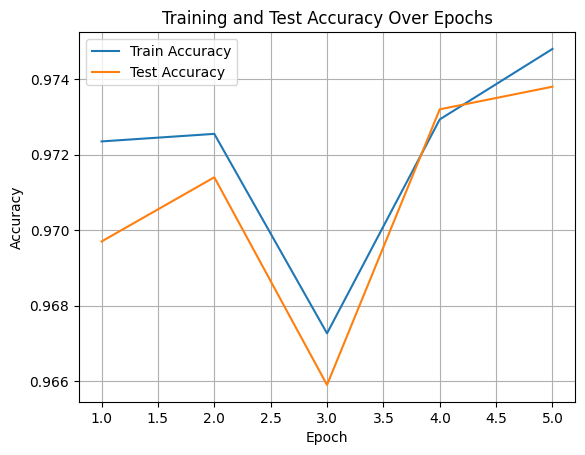

In [5]:
import matplotlib.pyplot as plt

# Only collect results and plot on the root process
if rank == 0:
    train_accuracies = []
    test_accuracies = []

    # Move plotting logic inside the training loop:
    for epoch in range(epochs):
        model = create_model()
        train_acc = train(model, x_train, y_train, rank, size)
        test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
        test_acc = comm.allreduce(test_acc, op=MPI.SUM)

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc / size)

        print(f"Epoch {epoch + 1}: Train Accuracy = {train_acc:.4f}, Test Accuracy = {test_acc / size:.4f}")

    # Plot the accuracy graph
    plt.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
    plt.plot(range(1, epochs + 1), test_accuracies, label='Test Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Test Accuracy Over Epochs")
    plt.legend()
    plt.grid(True)
    plt.show()
